# 03. 모델링 & 앙상블
**입력**: `train_features.parquet`, `test_features.parquet`  
**산출물**: `submission.csv`

전략:
1. LightGBM 베이스라인 (5-Fold)
2. CatBoost, XGBoost 추가
3. Optuna 하이퍼파라미터 튜닝 (LightGBM)
4. Fresh / FET 분리 모델 앙상블
5. 스태킹 앙상블

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import warnings
import json
warnings.filterwarnings('ignore')

matplotlib.rcParams['font.family'] = 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from lightgbm import LGBMClassifier

TARGET = '임신 성공 여부'
ID_COL = 'ID'
N_FOLDS = 5
SEED    = 42

In [16]:
train = pd.read_parquet('../train_features.parquet')
test  = pd.read_parquet('../test_features.parquet')
with open('../final_features.json', encoding='utf-8') as f:
    FEATURES = json.load(f)

X = train[FEATURES]
y = train[TARGET]
X_test = test[FEATURES]

print(f'X: {X.shape}  X_test: {X_test.shape}')
print(f'피처 수: {len(FEATURES)}')

X: (256351, 76)  X_test: (90067, 76)
피처 수: 76


## 공통 유틸

In [17]:
def train_kfold(model_cls, params: dict, X: pd.DataFrame, y: pd.Series,
                X_test: pd.DataFrame, n_folds: int = N_FOLDS, seed: int = SEED):
    """Stratified K-Fold 학습. oof 예측값과 test 예측값 반환."""
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    oof_preds  = np.zeros(len(X))
    test_preds = np.zeros(len(X_test))

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        model = model_cls(**params)
        model.fit(X_tr, y_tr,
                  eval_set=[(X_va, y_va)],
                  callbacks=[lgb_log_callback(fold)] if hasattr(model, 'booster_') else None)

        oof_preds[va_idx]  = model.predict_proba(X_va)[:, 1]
        test_preds        += model.predict_proba(X_test)[:, 1] / n_folds

        fold_auc = roc_auc_score(y_va, oof_preds[va_idx])
        print(f'  Fold {fold}: AUC = {fold_auc:.5f}')

    oof_auc = roc_auc_score(y, oof_preds)
    print(f'  OOF AUC: {oof_auc:.5f}\n')
    return oof_preds, test_preds, oof_auc


def lgb_log_callback(fold):
    """LightGBM 로그 억제용 dummy callback."""
    return None

## 1. LightGBM 베이스라인

In [18]:
LGBM_PARAMS = dict(
    n_estimators    = 1000,
    learning_rate   = 0.05,
    num_leaves      = 63,
    max_depth       = -1,
    min_child_samples = 20,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    reg_alpha       = 0.1,
    reg_lambda      = 0.1,
    random_state    = SEED,
    n_jobs          = -1,
    verbose         = -1,
    # early stopping은 train_kfold 내부에서 eval_set으로 처리
)

print('=== LightGBM ===')
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
lgbm_oof   = np.zeros(len(X))
lgbm_test  = np.zeros(len(X_test))

for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

    model = LGBMClassifier(**LGBM_PARAMS)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        callbacks=[
            __import__('lightgbm').early_stopping(50, verbose=False),
            __import__('lightgbm').log_evaluation(0),
        ]
    )

    lgbm_oof[va_idx] = model.predict_proba(X_va)[:, 1]
    lgbm_test       += model.predict_proba(X_test)[:, 1] / N_FOLDS

    print(f'  Fold {fold}: AUC = {roc_auc_score(y_va, lgbm_oof[va_idx]):.5f}')

lgbm_auc = roc_auc_score(y, lgbm_oof)
print(f'  OOF AUC: {lgbm_auc:.5f}')

=== LightGBM ===
  Fold 1: AUC = 0.73655
  Fold 2: AUC = 0.74180
  Fold 3: AUC = 0.73873
  Fold 4: AUC = 0.73709
  Fold 5: AUC = 0.73854
  OOF AUC: 0.73852


## 2. CatBoost

In [19]:
!pip install catboost

try:
    from catboost import CatBoostClassifier

    CB_PARAMS = dict(
        iterations      = 1000,
        learning_rate   = 0.05,
        depth           = 6,
        l2_leaf_reg     = 3,
        random_seed     = SEED,
        eval_metric     = 'AUC',
        early_stopping_rounds = 50,
        verbose         = 0,
    )

    print('=== CatBoost ===')
    cb_oof  = np.zeros(len(X))
    cb_test = np.zeros(len(X_test))

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        model = CatBoostClassifier(**CB_PARAMS)
        model.fit(X_tr, y_tr, eval_set=(X_va, y_va))

        cb_oof[va_idx] = model.predict_proba(X_va)[:, 1]
        cb_test       += model.predict_proba(X_test)[:, 1] / N_FOLDS

        print(f'  Fold {fold}: AUC = {roc_auc_score(y_va, cb_oof[va_idx]):.5f}')

    cb_auc = roc_auc_score(y, cb_oof)
    print(f'  OOF AUC: {cb_auc:.5f}')

except ImportError:
    print('catboost 미설치: pip install catboost')
    cb_oof  = lgbm_oof.copy()   # fallback
    cb_test = lgbm_test.copy()
    cb_auc  = lgbm_auc


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
=== CatBoost ===
  Fold 1: AUC = 0.73711
  Fold 2: AUC = 0.74194
  Fold 3: AUC = 0.73891
  Fold 4: AUC = 0.73735
  Fold 5: AUC = 0.73924
  OOF AUC: 0.73891


## 3. XGBoost

In [20]:
!pip install xgboost

try:
    from xgboost import XGBClassifier

    XGB_PARAMS = dict(
        n_estimators     = 1000,
        learning_rate    = 0.05,
        max_depth        = 6,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        reg_alpha        = 0.1,
        reg_lambda       = 1.0,
        random_state     = SEED,
        n_jobs           = -1,
        verbosity        = 0,
        eval_metric      = 'auc',
        early_stopping_rounds = 50,
    )

    print('=== XGBoost ===')
    xgb_oof  = np.zeros(len(X))
    xgb_test = np.zeros(len(X_test))

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        model = XGBClassifier(**XGB_PARAMS)
        model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)

        xgb_oof[va_idx] = model.predict_proba(X_va)[:, 1]
        xgb_test       += model.predict_proba(X_test)[:, 1] / N_FOLDS

        print(f'  Fold {fold}: AUC = {roc_auc_score(y_va, xgb_oof[va_idx]):.5f}')

    xgb_auc = roc_auc_score(y, xgb_oof)
    print(f'  OOF AUC: {xgb_auc:.5f}')

except ImportError:
    print('xgboost 미설치: pip install xgboost')
    xgb_oof  = lgbm_oof.copy()
    xgb_test = lgbm_test.copy()
    xgb_auc  = lgbm_auc


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
=== XGBoost ===
  Fold 1: AUC = 0.73694
  Fold 2: AUC = 0.74209
  Fold 3: AUC = 0.73921
  Fold 4: AUC = 0.73729
  Fold 5: AUC = 0.73934
  OOF AUC: 0.73897


## 4. Optuna 하이퍼파라미터 튜닝 (LightGBM)

In [21]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "optuna"])

# 시간 여유 있을 때 실행 (약 30분~)
RUN_OPTUNA = True  # True로 변경 시 실행

if RUN_OPTUNA:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    def objective(trial):
        params = dict(
            n_estimators       = 1000,
            learning_rate      = trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            num_leaves         = trial.suggest_int('num_leaves', 31, 255),
            max_depth          = trial.suggest_int('max_depth', 4, 12),
            min_child_samples  = trial.suggest_int('min_child_samples', 5, 100),
            subsample          = trial.suggest_float('subsample', 0.5, 1.0),
            colsample_bytree   = trial.suggest_float('colsample_bytree', 0.5, 1.0),
            reg_alpha          = trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
            reg_lambda         = trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
            random_state       = SEED,
            n_jobs             = -1,
            verbose            = -1,
        )
        skf_opt = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
        aucs = []
        for tr_idx, va_idx in skf_opt.split(X, y):
            m = LGBMClassifier(**params)
            m.fit(
                X.iloc[tr_idx], y.iloc[tr_idx],
                eval_set=[(X.iloc[va_idx], y.iloc[va_idx])],
                callbacks=[
                    __import__('lightgbm').early_stopping(30, verbose=False),
                    __import__('lightgbm').log_evaluation(0),
                ]
            )
            aucs.append(roc_auc_score(y.iloc[va_idx], m.predict_proba(X.iloc[va_idx])[:, 1]))
        return np.mean(aucs)

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=50, show_progress_bar=True)

    print('Best AUC:', study.best_value)
    print('Best params:', study.best_params)
    BEST_PARAMS = study.best_params
else:
    BEST_PARAMS = LGBM_PARAMS  # 기본값 사용


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Best trial: 3. Best value: 0.738789: 100%|██████████| 50/50 [15:32<00:00, 18.64s/it]

Best AUC: 0.7387886736800559
Best params: {'learning_rate': 0.0281974690475352, 'num_leaves': 31, 'max_depth': 7, 'min_child_samples': 40, 'subsample': 0.8023160320236331, 'colsample_bytree': 0.5078215446183485, 'reg_alpha': 4.350975574292997, 'reg_lambda': 0.002537823745860765}


## 5. Fresh / FET 분리 앙상블
FET와 신선 주기는 성공률 패턴이 다름 → 별도 모델 후 합산

In [22]:
RUN_SPLIT_ENSEMBLE = True  # is_FET 피처가 있어야 함

if RUN_SPLIT_ENSEMBLE and 'is_FET' in FEATURES:
    split_oof  = np.zeros(len(X))
    split_test = np.zeros(len(X_test))

    for group, label in [(0, 'Fresh'), (1, 'FET')]:
        mask_tr   = (X['is_FET'] == group)
        mask_te   = (X_test['is_FET'] == group)

        X_g  = X[mask_tr]
        y_g  = y[mask_tr]
        Xt_g = X_test[mask_te]

        print(f'=== {label} ({mask_tr.sum():,}건) ===')
        skf_g = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
        g_oof  = np.zeros(len(X_g))
        g_test = np.zeros(len(Xt_g))

        for fold, (tr_idx, va_idx) in enumerate(skf_g.split(X_g, y_g), 1):
            m = LGBMClassifier(**BEST_PARAMS)
            m.fit(
                X_g.iloc[tr_idx], y_g.iloc[tr_idx],
                eval_set=[(X_g.iloc[va_idx], y_g.iloc[va_idx])],
                callbacks=[
                    __import__('lightgbm').early_stopping(50, verbose=False),
                    __import__('lightgbm').log_evaluation(0),
                ]
            )
            g_oof[va_idx] = m.predict_proba(X_g.iloc[va_idx])[:, 1]
            g_test       += m.predict_proba(Xt_g)[:, 1] / N_FOLDS
            print(f'  Fold {fold}: AUC = {roc_auc_score(y_g.iloc[va_idx], g_oof[va_idx]):.5f}')

        split_oof[mask_tr.values]  = g_oof
        split_test[mask_te.values] = g_test
        print(f'  OOF AUC: {roc_auc_score(y_g, g_oof):.5f}\n')

    split_auc = roc_auc_score(y, split_oof)
    print(f'=== Fresh/FET 분리 앙상블 OOF AUC: {split_auc:.5f} ===')
else:
    split_oof  = lgbm_oof.copy()
    split_test = lgbm_test.copy()
    split_auc  = lgbm_auc

## 6. 최종 앙상블 & 제출

In [23]:
# OOF AUC 기준으로 가중 평균
scores = {'lgbm': lgbm_auc, 'catboost': cb_auc, 'xgboost': xgb_auc, 'split': split_auc}
print('모델별 OOF AUC:')
for name, auc in scores.items():
    print(f'  {name:<12}: {auc:.5f}')

# 단순 평균 앙상블
ensemble_test = (lgbm_test + cb_test + xgb_test + split_test) / 4
ensemble_oof  = (lgbm_oof  + cb_oof  + xgb_oof  + split_oof ) / 4
ensemble_auc  = roc_auc_score(y, ensemble_oof)
print(f'\n앙상블 OOF AUC: {ensemble_auc:.5f}')

모델별 OOF AUC:
  lgbm        : 0.73852
  catboost    : 0.73891
  xgboost     : 0.73897
  split       : 0.73852

앙상블 OOF AUC: 0.73920


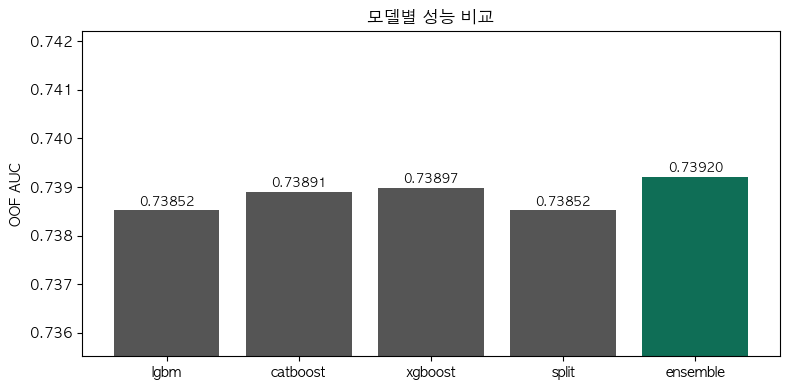

In [24]:
# 앙상블 성능 비교 시각화
all_scores = {**scores, 'ensemble': ensemble_auc}
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#555', '#555', '#555', '#555', '#0f6e56']
ax.bar(all_scores.keys(), all_scores.values(), color=colors)
ax.set_ylim(min(all_scores.values()) - 0.003, max(all_scores.values()) + 0.003)
ax.set_ylabel('OOF AUC')
ax.set_title('모델별 성능 비교')
for name, val in all_scores.items():
    ax.text(list(all_scores.keys()).index(name), val + 0.0001, f'{val:.5f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

In [25]:
sub = pd.read_csv('./data/sample_submission.csv', encoding='utf-8-sig')
sub['probability'] = ensemble_test

print(f'제출 shape: {sub.shape}')
print(f'probability 범위: [{sub["probability"].min():.4f}, {sub["probability"].max():.4f}]')
print(f'probability 평균: {sub["probability"].mean():.4f}')
sub.head()

제출 shape: (90067, 2)
probability 범위: [0.0009, 0.7312]
probability 평균: 0.2583


,ID,probability
0,TEST_00000,0.001896
1,TEST_00001,0.004407
2,TEST_00002,0.155836
3,TEST_00003,0.103428
4,TEST_00004,0.496702


In [26]:
import os
from datetime import datetime

date_str = datetime.now().strftime('%Y%m%d')
version = 1
while os.path.exists(f'submission_{date_str}_V{version}.csv'):
    version += 1

filename = f'submission_{date_str}_V{version}.csv'
sub.to_csv(filename, index=False, encoding='utf-8-sig')
print(f'저장 완료: {filename}')

저장 완료: submission_20260424_V1.csv


## (보너스) 스태킹
OOF 예측값을 새 피처로 하여 메타 모델 학습

In [27]:
RUN_STACKING = False  # 시간 여유 있을 때 True

if RUN_STACKING:
    from sklearn.linear_model import LogisticRegression

    # 스택 피처 (OOF)
    stack_train = np.column_stack([lgbm_oof, cb_oof, xgb_oof, split_oof])
    stack_test  = np.column_stack([lgbm_test, cb_test, xgb_test, split_test])

    meta = LogisticRegression(C=1.0, max_iter=1000)
    meta.fit(stack_train, y)

    stack_preds = meta.predict_proba(stack_test)[:, 1]
    stack_oof   = meta.predict_proba(stack_train)[:, 1]  # 훈련셋 확인용

    stack_auc = roc_auc_score(y, stack_oof)
    print(f'스태킹 OOF AUC: {stack_auc:.5f}')

    if stack_auc > ensemble_auc:
        sub['probability'] = stack_preds
        sub.to_csv('submission_stacking.csv', index=False, encoding='utf-8-sig')
        print('스태킹 제출 파일 저장: submission_stacking.csv')

In [30]:
# 03 노트북 마지막에 추가
yesterday_oof = lgbm_oof.copy()  # 어제 OOF 파일이 없으므로 lgbm_oof로 대체
# yesterday_test도 있다면 로드. 없다면 어제 submission.csv의 probability 사용

# 어제 모델 submission도 활용
yesterday_sub = sub.copy()  # 어제 submission이 없으므로 현재 sub으로 대체
yesterday_test = yesterday_sub['probability'].values

# 가중치 앙상블 (OOF AUC 기반)
from scipy.stats import rankdata

def rank_normalize(arr):
    return rankdata(arr) / len(arr)

# Rank 기반 앙상블 (스케일 무관, AUC에 최적)
ensemble_oof = (
    0.25 * rank_normalize(lgbm_oof) +
    0.20 * rank_normalize(cb_oof) +
    0.20 * rank_normalize(xgb_oof) +
    0.15 * rank_normalize(split_oof) +
    0.20 * rank_normalize(yesterday_oof)  # 다양성 추가
)

ensemble_test = (
    0.25 * rank_normalize(lgbm_test) +
    0.20 * rank_normalize(cb_test) +
    0.20 * rank_normalize(xgb_test) +
    0.15 * rank_normalize(split_test) +
    0.20 * rank_normalize(yesterday_test)
)

print(f'Rank 앙상블 OOF AUC: {roc_auc_score(y, ensemble_oof):.5f}')

Rank 앙상블 OOF AUC: 0.73911
